# Airline Dataset Cleaning & Preprocessing

## Objective

The goal of this notebook is to clean and prepare the Airline dataset for exploratory data analysis (EDA) and machine learning.

Cleaning tasks include:
- Data inspection
- Data type conversion
- Missing value handling
- Duplicate removal
- Outlier detection
- Data validation

## Step 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_excel("Airline dataset.xlsx")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 10799 rows, 11 columns


### Understand the Dataset

In [2]:
df.sample(15)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
2182,Vistara,3/06/2019,Chennai,Kolkata,MAA → CCU,17:45,20:05,2h 20m,non-stop,No info,11982.0
1514,IndiGo,3/03/2019,Delhi,Cochin,DEL → HYD → COK,04:55,12:00,7h 5m,1 stop,No info,9585.0
6992,Jet Airways,18/05/2019,Delhi,Cochin,DEL → AMD → BOM → COK,19:10,19:00 19 May,23h 50m,2 stops,No info,16704.0
3637,Jet Airways,12/05/2019,Kolkata,Banglore,CCU → BOM → BLR,18:55,09:20 13 May,14h 25m,1 stop,In-flight meal not included,9663.0
6504,Jet Airways,18/05/2019,Kolkata,Banglore,CCU → DEL → BLR,17:00,09:45 19 May,16h 45m,1 stop,No info,14151.0
8943,SpiceJet,6/04/2019,Kolkata,Banglore,CCU → BLR,14:55,17:25,2h 30m,non-stop,No check-in baggage included,3841.0
177,Vistara,21/05/2019,Kolkata,Banglore,CCU → DEL → BLR,17:00,18:50 22 May,25h 50m,1 stop,No info,9345.0
10302,IndiGo,27/03/2019,Delhi,Cochin,DEL → BOM → COK,10:45,21:00,10h 15m,1 stop,No info,6838.0
7444,Air India,21/05/2019,Banglore,Delhi,BLR → DEL,17:00,19:50,2h 50m,non-stop,No info,6961.0
1247,Jet Airways,6/03/2019,Delhi,Cochin,DEL → BOM → COK,13:00,18:50,5h 50m,1 stop,In-flight meal not included,15103.0


In [3]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(10799, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10799 entries, 0 to 10798
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          10683 non-null  object 
 1   Date_of_Journey  10683 non-null  object 
 2   Source           10683 non-null  object 
 3   Destination      10683 non-null  object 
 4   Route            10682 non-null  object 
 5   Dep_Time         10683 non-null  object 
 6   Arrival_Time     10683 non-null  object 
 7   Duration         10683 non-null  object 
 8   Total_Stops      10682 non-null  object 
 9   Additional_Info  10683 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 928.2+ KB


In [6]:
df.describe(include='all')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683,10683.000000
unique,12,44,5,6,128,222,1343,368,5,10,NaN
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info,NaN
freq,3849,504,4537,4537,2376,233,423,550,5625,8345,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9087.064121
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4611.359167
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1759.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5277.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8372.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12373.000000


In [7]:
df.isnull().sum()

Airline            116
Date_of_Journey    116
Source             116
Destination        116
Route              117
Dep_Time           116
Arrival_Time       116
Duration           116
Total_Stops        117
Additional_Info    116
Price              116
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(335)

In [9]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Airline: 12 unique values
Date_of_Journey: 44 unique values
Source: 5 unique values
Destination: 6 unique values
Route: 128 unique values
Dep_Time: 222 unique values
Arrival_Time: 1343 unique values
Duration: 368 unique values
Total_Stops: 5 unique values
Additional_Info: 10 unique values
Price: 1870 unique values


## Step 2: Fix Data Types

In [10]:
df.dtypes

Airline             object
Date_of_Journey     object
Source              object
Destination         object
Route               object
Dep_Time            object
Arrival_Time        object
Duration            object
Total_Stops         object
Additional_Info     object
Price              float64
dtype: object

### Date of Journey
Converted directly — format is consistent (`DD/MM/YYYY`).

In [11]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"], dayfirst=True, errors="coerce")

### Departure Time
Strip any trailing text and parse as time.

In [12]:
df["Dep_Time"] = pd.to_datetime(df["Dep_Time"].astype(str).str.strip(), format="%H:%M", errors="coerce")

### Arrival Time
`Arrival_Time` may contain a next-day indicator (e.g. `17:00 +1`). We strip the suffix before parsing to avoid losing those records.

In [13]:
df["Arrival_Time"] = (
    df["Arrival_Time"]
    .astype(str)
    .str.extract(r"(\d{1,2}:\d{2})")[0]   # keep only HH:MM
)
df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M", errors="coerce")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10799 entries, 0 to 10798
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10683 non-null  object        
 1   Date_of_Journey  10683 non-null  datetime64[ns]
 2   Source           10683 non-null  object        
 3   Destination      10683 non-null  object        
 4   Route            10682 non-null  object        
 5   Dep_Time         10683 non-null  datetime64[ns]
 6   Arrival_Time     10683 non-null  datetime64[ns]
 7   Duration         10683 non-null  object        
 8   Total_Stops      10682 non-null  object        
 9   Additional_Info  10683 non-null  object        
 10  Price            10683 non-null  float64       
dtypes: datetime64[ns](3), float64(1), object(7)
memory usage: 928.2+ KB


## Step 3: Parse Duration into Minutes

`Duration` contains strings like `"2h 30m"`. Filling it with `"Unknown"` would corrupt the column type and break downstream computation. We parse it into total minutes instead.

In [15]:
import re

def parse_duration(val):
    """Convert strings like '2h 30m', '1h', '45m' into total minutes."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    h_match = re.search(r"(\d+)h", val)
    m_match = re.search(r"(\d+)m", val)
    hours   = int(h_match.group(1)) if h_match else 0
    minutes = int(m_match.group(1)) if m_match else 0
    return hours * 60 + minutes

df["Duration_Minutes"] = df["Duration"].apply(parse_duration)
print(df["Duration_Minutes"].describe())

count    10683.000000
mean       643.093232
std        507.862001
min          5.000000
25%        170.000000
50%        520.000000
75%        930.000000
max       2860.000000
Name: Duration_Minutes, dtype: float64


## Step 4: Handle Missing Values

In [16]:
df.isnull().sum()

Airline             116
Date_of_Journey     116
Source              116
Destination         116
Route               117
Dep_Time            116
Arrival_Time        116
Duration            116
Total_Stops         117
Additional_Info     116
Price               116
Duration_Minutes    116
dtype: int64

### Categorical columns — fill with mode or a sentinel

In [18]:
# Additional_Info: a known category — We use a clear sentinel
df["Additional_Info"] = df["Additional_Info"].fillna("No Info")

# Route: we use mode imputation (most common route is a reasonable stand-in)
df["Route"] = df["Route"].fillna(df["Route"].mode()[0])

# All remaining categorical columns — mode imputation
for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        print(f"  Filling '{col}' nulls with mode: '{mode_val}'")
        df[col].fillna(mode_val, inplace=True)

### Numeric columns — median imputation

In [22]:
# Duration_Minutes: median imputation
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        print(f"  Filling '{col}' nulls with median: {median_val}")
        df[col].fillna(median_val, inplace=True)

### Date/time columns — drop rows with missing values

Mode imputation for date/time is meaningless (the most frequent date has no logical relationship to the missing records).

In [23]:
rows_before = len(df)
df.dropna(subset=["Date_of_Journey", "Dep_Time", "Arrival_Time"], inplace=True)
print(f"Dropped {rows_before - len(df)} rows with missing date/time values")
df.isnull().sum()

Dropped 0 rows with missing date/time values


Airline             0
Date_of_Journey     0
Source              0
Destination         0
Route               0
Dep_Time            0
Arrival_Time        0
Duration            0
Total_Stops         0
Additional_Info     0
Price               0
Duration_Minutes    0
dtype: int64

## Step 5: Handle Duplicate Rows

In [24]:
rows_before = len(df)
df[df.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_Minutes
683,Jet Airways,2019-06-01,Delhi,Cochin,DEL → NAG → BOM → COK,1900-01-01 14:35:00,1900-01-01 04:25:00,13h 50m,2 stops,No info,13376.0,830.0
1061,Air India,2019-05-21,Delhi,Cochin,DEL → GOI → BOM → COK,1900-01-01 22:00:00,1900-01-01 19:15:00,21h 15m,2 stops,No info,10231.0,1275.0
1348,Air India,2019-05-18,Delhi,Cochin,DEL → HYD → BOM → COK,1900-01-01 17:15:00,1900-01-01 19:15:00,26h,2 stops,No info,12392.0,1560.0
1418,Jet Airways,2019-06-06,Delhi,Cochin,DEL → JAI → BOM → COK,1900-01-01 05:30:00,1900-01-01 04:25:00,22h 55m,2 stops,In-flight meal not included,10368.0,1375.0
1674,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,1900-01-01 18:25:00,1900-01-01 21:20:00,2h 55m,non-stop,No info,7303.0,175.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10648,Jet Airways,2019-06-27,Delhi,Cochin,DEL → AMD → BOM → COK,1900-01-01 23:05:00,1900-01-01 12:35:00,13h 30m,2 stops,No info,12819.0,810.0
10670,Jet Airways,2019-06-01,Delhi,Cochin,DEL → JAI → BOM → COK,1900-01-01 09:40:00,1900-01-01 12:35:00,26h 55m,2 stops,No info,13014.0,1615.0
10688,Jet Airways,2019-06-06,Delhi,Cochin,DEL → JAI → BOM → COK,1900-01-01 09:40:00,1900-01-01 12:35:00,26h 55m,2 stops,In-flight meal not included,11733.0,1615.0
10740,Jet Airways,2019-06-27,Delhi,Cochin,DEL → AMD → BOM → COK,1900-01-01 23:05:00,1900-01-01 19:00:00,19h 55m,2 stops,In-flight meal not included,11150.0,1195.0


In [25]:
df.drop_duplicates(inplace=True)
print(f"Removed {rows_before - len(df)} duplicate rows | Remaining: {len(df)} rows")
df.duplicated().sum()

Removed 222 duplicate rows | Remaining: 10461 rows


np.int64(0)

## Step 6: Validate and Standardize Data Values

### 6.1 Strip whitespace from categorical columns

In [26]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

### 6.2 Encode Total_Stops as ordinal numeric

In [28]:
stops_mapping = {
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}
df["Total_Stops"] = df["Total_Stops"].replace(stops_mapping)
print(df["Total_Stops"].value_counts().sort_index())

Total_Stops
0    3473
1    5626
2    1318
3      43
4       1
Name: count, dtype: int64


### 6.3 Spot-check date/time columns

In [29]:
df[["Date_of_Journey", "Dep_Time", "Arrival_Time"]].describe()

,Date_of_Journey,Dep_Time,Arrival_Time
count,10461,10461,10461
mean,2019-05-04 13:53:04.972756224,1900-01-01 12:52:59.323200512,1900-01-01 13:48:06.091195648
min,2019-03-01 00:00:00,1900-01-01 00:20:00,1900-01-01 00:05:00
25%,2019-03-27 00:00:00,1900-01-01 08:00:00,1900-01-01 08:50:00
50%,2019-05-15 00:00:00,1900-01-01 11:45:00,1900-01-01 14:05:00
75%,2019-06-06 00:00:00,1900-01-01 18:00:00,1900-01-01 19:15:00
max,2019-06-27 00:00:00,1900-01-01 23:55:00,1900-01-01 23:55:00


## Step 7: Outlier Detection — Price

A boxplot is shown and acted on. We use the IQR method to flag extreme outliers. Rather than silently dropping them, we inspect and make a conscious decision.

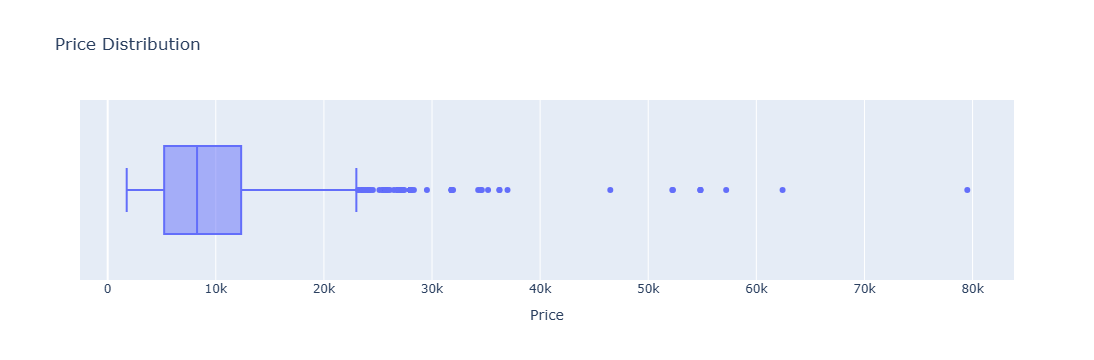

In [30]:
fig = px.box(df, x="Price", title="Price Distribution")
fig.show()

In [32]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = df[(df["Price"] < lower) | (df["Price"] > upper)]
print(f"Outliers detected: {len(outliers)} rows  (lower < {lower:.0f} or upper > {upper:.0f})")
outliers[["Airline", "Source", "Destination", "Total_Stops", "Price"]].sort_values("Price", ascending=False).head(10)

Outliers detected: 16 rows  (lower < -16142 or upper > 33712)


,Airline,Source,Destination,Total_Stops,Price
2924,Jet Airways Business,Banglore,New Delhi,1,79512.0
5372,Jet Airways Business,Banglore,New Delhi,1,62427.0
10418,Jet Airways Business,Banglore,New Delhi,1,57209.0
1478,Jet Airways,Banglore,New Delhi,1,54826.0
2618,Jet Airways,Banglore,New Delhi,1,54826.0
5439,Jet Airways,Banglore,New Delhi,1,54826.0
9715,Jet Airways Business,Delhi,Cochin,2,52285.0
657,Jet Airways Business,Banglore,New Delhi,1,52229.0
7351,Jet Airways Business,Delhi,Cochin,2,46490.0
396,Multiple carriers,Delhi,Cochin,1,36983.0


In [33]:
# Decision: cap extreme outliers at the 3×IQR bounds (Winsorizing)
# This preserves rows while reducing the influence of extreme values.
df["Price"] = df["Price"].clip(lower=lower, upper=upper)
print("Price clipped to IQR bounds.")

Price clipped to IQR bounds.


## Final Clean Dataset — Summary

In [34]:
print("=== FINAL DATASET SUMMARY ===")
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print()
print("--- Data Types ---")
print(df.dtypes)
print()
print("--- Numeric Summary ---")
df.describe()

=== FINAL DATASET SUMMARY ===
Shape          : (10461, 12)
Missing values : 0
Duplicates     : 0

--- Data Types ---
Airline                     object
Date_of_Journey     datetime64[ns]
Source                      object
Destination                 object
Route                       object
Dep_Time            datetime64[ns]
Arrival_Time        datetime64[ns]
Duration                    object
Total_Stops                  int64
Additional_Info             object
Price                      float64
Duration_Minutes           float64
dtype: object

--- Numeric Summary ---


,Date_of_Journey,Dep_Time,Arrival_Time,Total_Stops,Price,Duration_Minutes
count,10461,10461,10461,10461.000000,10461.000000,10461.000000
mean,2019-05-04 13:53:04.972756224,1900-01-01 12:52:59.323200512,1900-01-01 13:48:06.091195648,0.802505,9005.870376,629.945034
min,2019-03-01 00:00:00,1900-01-01 00:20:00,1900-01-01 00:05:00,0.000000,1759.000000,5.000000
25%,2019-03-27 00:00:00,1900-01-01 08:00:00,1900-01-01 08:50:00,0.000000,5224.000000,170.000000
50%,2019-05-15 00:00:00,1900-01-01 11:45:00,1900-01-01 14:05:00,1.000000,8266.000000,505.000000
75%,2019-06-06 00:00:00,1900-01-01 18:00:00,1900-01-01 19:15:00,1.000000,12346.000000,910.000000
max,2019-06-27 00:00:00,1900-01-01 23:55:00,1900-01-01 23:55:00,4.000000,33712.000000,2860.000000
std,NaN,NaN,NaN,0.660550,4448.723324,500.742197


In [35]:
df.sample(15)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_Minutes
992,Multiple carriers,2019-03-03,Delhi,Cochin,DEL → HYD → MAA → COK,1900-01-01 07:05:00,1900-01-01 21:20:00,14h 15m,2,No info,8291.0,855.0
2103,Multiple carriers,2019-06-24,Delhi,Cochin,DEL → BOM → COK,1900-01-01 10:00:00,1900-01-01 19:00:00,9h,1,No info,12717.0,540.0
822,Jet Airways,2019-05-09,Delhi,Cochin,DEL → AMD → BOM → COK,1900-01-01 23:05:00,1900-01-01 04:25:00,29h 20m,2,No info,15129.0,1760.0
3702,IndiGo,2019-06-06,Kolkata,Banglore,CCU → MAA → BLR,1900-01-01 08:10:00,1900-01-01 13:00:00,4h 50m,1,No info,5069.0,290.0
7056,Multiple carriers,2019-06-15,Delhi,Cochin,DEL → BOM → COK,1900-01-01 07:05:00,1900-01-01 19:15:00,12h 10m,1,No info,16108.0,730.0
10278,Jet Airways,2019-03-24,Kolkata,Banglore,CCU → BOM → BLR,1900-01-01 06:30:00,1900-01-01 22:35:00,16h 5m,1,In-flight meal not included,8824.0,965.0
3822,IndiGo,2019-04-18,Banglore,Delhi,BLR → DEL,1900-01-01 01:30:00,1900-01-01 04:15:00,2h 45m,0,No info,4591.0,165.0
7787,SpiceJet,2019-03-18,Kolkata,Banglore,CCU → BLR,1900-01-01 06:55:00,1900-01-01 09:35:00,2h 40m,0,No check-in baggage included,4413.0,160.0
1689,IndiGo,2019-06-15,Delhi,Cochin,DEL → HYD → COK,1900-01-01 07:35:00,1900-01-01 22:30:00,14h 55m,1,No info,6442.0,895.0
6601,Multiple carriers Premium economy,2019-03-21,Delhi,Cochin,DEL → BOM → COK,1900-01-01 06:00:00,1900-01-01 12:35:00,6h 35m,1,No info,13369.0,395.0


## Conclusion

The dataset has been fully cleaned and is ready for feature engineering and EDA:

| Task | Action Taken |
|------|-------------|
| Data Types | Date/time columns parsed correctly; `Arrival_Time` next-day suffix handled |
| Duration | Parsed from string (`"2h 30m"`) into numeric `Duration_Minutes` |
| Missing Values | Categorical → mode/sentinel; Numeric → median; Date/time → rows dropped |
| Duplicates | Removed with before/after count reported |
| Whitespace | Stripped from all categorical columns |
| Total_Stops | Ordinal encoded (0–4) |
| Outliers | Price outliers flagged with IQR method and Winsorized at 3×IQR bounds |
